# Proyecto: Modelo de Clasificación con Explainable AI usando solo SHAP

Este notebook muestra, de principio a fin, cómo:

- Entrenar un modelo de **clasificación** sobre el dataset de cáncer de mama (*Breast Cancer Wisconsin*).
- Evaluar su desempeño de forma básica.
- Explicar sus predicciones usando **Explainable AI**, específicamente **SHAP (SHapley Additive exPlanations)**.
- Extraer **conclusiones** tanto técnicas como de negocio.

El objetivo es que cualquier lector (estudiante, científico de datos o profesional de negocio) pueda:

1. Entender el **caso de uso**.
2. Comprender **qué es SHAP** y para qué sirve.
3. Seguir el **detalle de cada línea de código**.
4. Interpretar las **gráficas de SHAP** a nivel global y local.


## Explicación del caso

Imaginemos que trabajamos con un hospital que quiere un sistema de apoyo a la decisión que clasifique tumores como:

- **Malignos (0)** → riesgo alto, requieren atención urgente.
- **Benignos (1)** → riesgo menor, posible seguimiento menos agresivo.

El dataset **Breast Cancer Wisconsin** de `scikit-learn` contiene:

- Variables numéricas derivadas de imágenes de tumores (radio, textura, área, concavidad, etc.).
- Una etiqueta que indica si el tumor es maligno o benigno.

Nuestro objetivo:

- Entrenar un modelo de Machine Learning (Random Forest).
- Lograr un buen desempeño.
- **Explicar sus decisiones** usando SHAP, de forma que:

  - Un médico pueda entender qué características influyen más.
  - Un comité ético o regulatorio pueda auditar las decisiones.


## ¿Qué es SHAP y para qué sirve?

**SHAP (SHapley Additive exPlanations)** es un método de explicabilidad basado en los **valores de Shapley** de la teoría de juegos cooperativos.

### Intuición

- Piense en cada característica (*feature*) como en un "jugador" que participa en un juego.
- La predicción del modelo es el "resultado" del juego.
- SHAP calcula **cuánto aporta cada jugador**, en promedio, a ese resultado, considerando todas las combinaciones posibles de jugadores.

### ¿Qué ofrece SHAP en la práctica?

- **Explicaciones globales**:
  - ¿Qué variables son, en promedio, las más influyentes en el modelo?

- **Explicaciones locales**:
  - Para un paciente específico: ¿qué características empujan la predicción hacia *maligno* o *benigno*?

### Por qué es útil en este proyecto

En un contexto médico o regulado:

- No basta con tener un modelo con alta accuracy.
- Es necesario saber **por qué** el modelo predice algo.
- SHAP proporciona explicaciones **matemáticamente sólidas** y visualmente interpretables, lo que lo hace adecuado para:
  - Documentación del modelo.
  - Auditorías.
  - Discusiones con expertos del dominio (médicos, comités éticos, etc.).


## 1. Instalación de librerías
A continuación instalamos las librerías necesarias para el notebook.

## 2. Importación y configuración
Importamos todas las librerías que utilizaremos y configuramos el estilo de gráficos.

## 3. Carga y exploración del dataset
Cargamos el dataset de cáncer de mama, creamos un `DataFrame` y analizamos su estructura básica.

### 3.1 Exploración inicial
Revisamos algunas estadísticas básicas y la distribución de clases.

## 4. Entrenamiento del modelo
Dividimos los datos en entrenamiento y prueba, entrenamos un Random Forest y evaluamos su desempeño.

## 5. Importancia clásica de características
Usamos la importancia nativa del Random Forest para ver qué variables son más relevantes de forma global.

## 6. SHAP Global
Calculamos valores SHAP para todo el conjunto de prueba y generamos un `summary_plot` que muestra el impacto global de cada característica.

## 7. SHAP Local
Elegimos una instancia específica (un 'paciente') y analizamos cómo contribuye cada característica a su predicción mediante un `force_plot`.

## 8. Conclusiones

En esta sección resumiremos:

- El desempeño del modelo de clasificación.
- Qué variables tienen más influencia globalmente.
- Cómo SHAP ayuda a entender casos específicos.
- Cómo podría integrarse este enfoque en un contexto real (por ejemplo, en un flujo de trabajo médico o corporativo).


In [1]:
# ============================================
# 1. Instalación de librerías
# ============================================
# En Google Colab, podemos instalar librerías adicionales con pip.
# Aquí instalamos:
# - shap: para explicabilidad
# - scikit-learn: para el modelo de machine learning
# - matplotlib y seaborn: para visualizaciones
!pip install shap scikit-learn matplotlib seaborn --quiet


In [2]:
# ============================================
# 2. Importación y configuración
# ============================================

# NumPy: operaciones numéricas eficientes
import numpy as np

# pandas: manipulación de datos en formato tabla (DataFrame)
import pandas as pd

# shap: librería de Explainable AI basada en valores de Shapley
import shap

# Conjunto de datos y utilidades de scikit-learn
from sklearn.datasets import load_breast_cancer            # Dataset de cáncer de mama
from sklearn.model_selection import train_test_split       # Para dividir en train/test
from sklearn.ensemble import RandomForestClassifier        # Modelo Random Forest
from sklearn.metrics import classification_report, accuracy_score  # Métricas de evaluación

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Inicializamos la parte visual de SHAP (útil en notebooks)
shap.initjs()

# Configuramos el estilo de los gráficos para que sean más agradables
sns.set(style='whitegrid', context='notebook')

print("Librerías importadas y entorno configurado correctamente.")


Librerías importadas y entorno configurado correctamente.


In [3]:
# ============================================
# 3. Carga del dataset
# ============================================

# Cargamos el dataset Breast Cancer desde scikit-learn.
# 'data' es un objeto tipo 'Bunch' similar a un diccionario.
data = load_breast_cancer()

# X contendrá las variables predictoras (features).
# data.data es un arreglo NumPy con las características numéricas.
# data.feature_names son los nombres de las columnas.
X = pd.DataFrame(data.data, columns=data.feature_names)

# y contendrá la variable objetivo (0 = malignant, 1 = benign).
y = data.target

# Guardamos también los nombres de las características y de las clases
feature_names = data.feature_names
class_names = data.target_names

print("Dimensiones de X:", X.shape)   # (n_muestras, n_características)
print("Dimensiones de y:", y.shape)   # (n_muestras,)
print("Clases del problema:", class_names)

# Mostramos las primeras filas para hacernos una idea del formato
X.head()


Dimensiones de X: (569, 30)
Dimensiones de y: (569,)
Clases del problema: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Descripción estadística (primeras 10 variables):


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744



Distribución de clases:


,count
malignant,212
benign,357


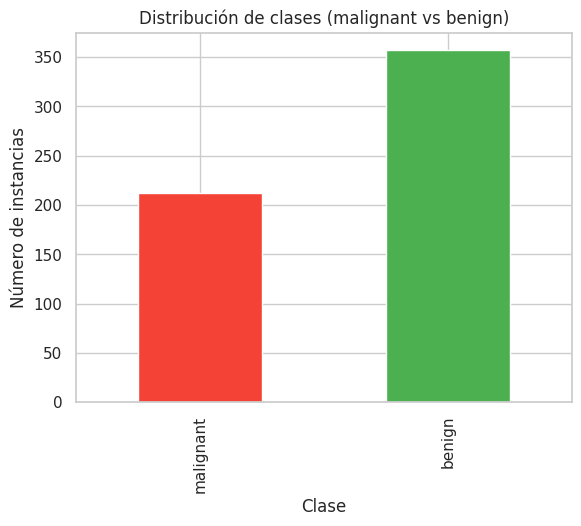

In [4]:
# ============================================
# 3.1 Exploración inicial del dataset
# ============================================

# Resumen estadístico de las primeras 10 variables:
# Incluye media, desviación estándar, valores mínimo/máximo, etc.
print("Descripción estadística (primeras 10 variables):")
display(X.describe().T.head(10))

# Ahora analizamos la distribución de clases (maligno vs benigno).
class_counts = pd.Series(y).value_counts().sort_index()  # Conteo por clase (0 y 1)
class_counts.index = class_names                         # Reemplazamos índice numérico por nombre de clase

print("\nDistribución de clases:")
display(class_counts)

# Visualizamos la distribución de clases con un gráfico de barras.
class_counts.plot(kind='bar', color=['#F44336', '#4CAF50'])  # Rojo para malignant, verde para benign
plt.title('Distribución de clases (malignant vs benign)')
plt.ylabel('Número de instancias')
plt.xlabel('Clase')
plt.show()


In [5]:
# ============================================
# 4. Entrenamiento del modelo
# ============================================

# Dividimos los datos en entrenamiento y prueba.
# - test_size=0.25 → 25% de los datos se usan para prueba.
# - stratify=y → mantiene la proporción de clases en train y test.
# - random_state=42 → fija la semilla para reproducibilidad.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

# Definimos el modelo Random Forest:
# - n_estimators=300 → número de árboles en el bosque.
# - max_depth=6 → profundidad máxima de cada árbol (controla complejidad).
# - random_state=42 → reproducibilidad.
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

# Entrenamos el modelo con los datos de entrenamiento.
model.fit(X_train, y_train)

# Generamos predicciones sobre el conjunto de prueba.
y_pred = model.predict(X_test)

# Mostramos un reporte de clasificación con métricas por clase.
print("=== Reporte de clasificación (conjunto de prueba) ===")
print(classification_report(y_test, y_pred, target_names=class_names))

# Calculamos y mostramos el accuracy global.
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy global: {acc:.4f}")


Tamaño del conjunto de entrenamiento: (426, 30)
Tamaño del conjunto de prueba: (143, 30)
=== Reporte de clasificación (conjunto de prueba) ===
              precision    recall  f1-score   support

   malignant       0.96      0.92      0.94        53
      benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143

Accuracy global: 0.9580


/tmp/ipython-input-1705099161.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


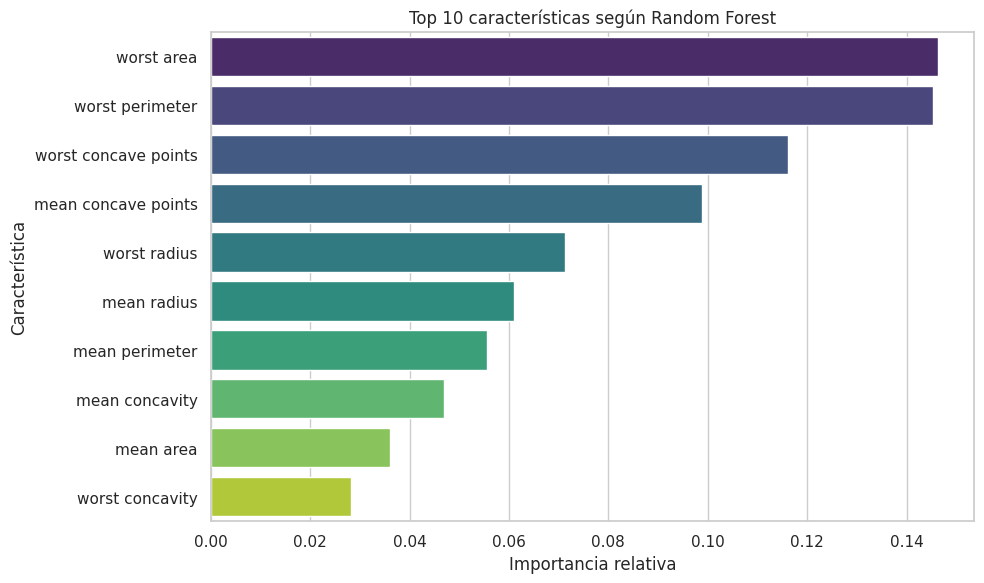

In [6]:
# ============================================
# 5. Importancia clásica de características
# ============================================

# Obtenemos la importancia de cada característica según el Random Forest.
# Esta importancia suele basarse en la reducción de impureza promedio.
importances = model.feature_importances_

# Obtenemos los índices que ordenarían las importancias de mayor a menor.
indices = np.argsort(importances)[::-1]

# Número de características que queremos mostrar (las top N).
top_n = 10

# Creamos un gráfico de barras con las top N características más importantes.
plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances[indices][:top_n],           # Importancias ordenadas
    y=X.columns[indices][:top_n],             # Nombres de las características correspondientes
    palette='viridis'
)
plt.title(f'Top {top_n} características según Random Forest')
plt.xlabel('Importancia relativa')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()


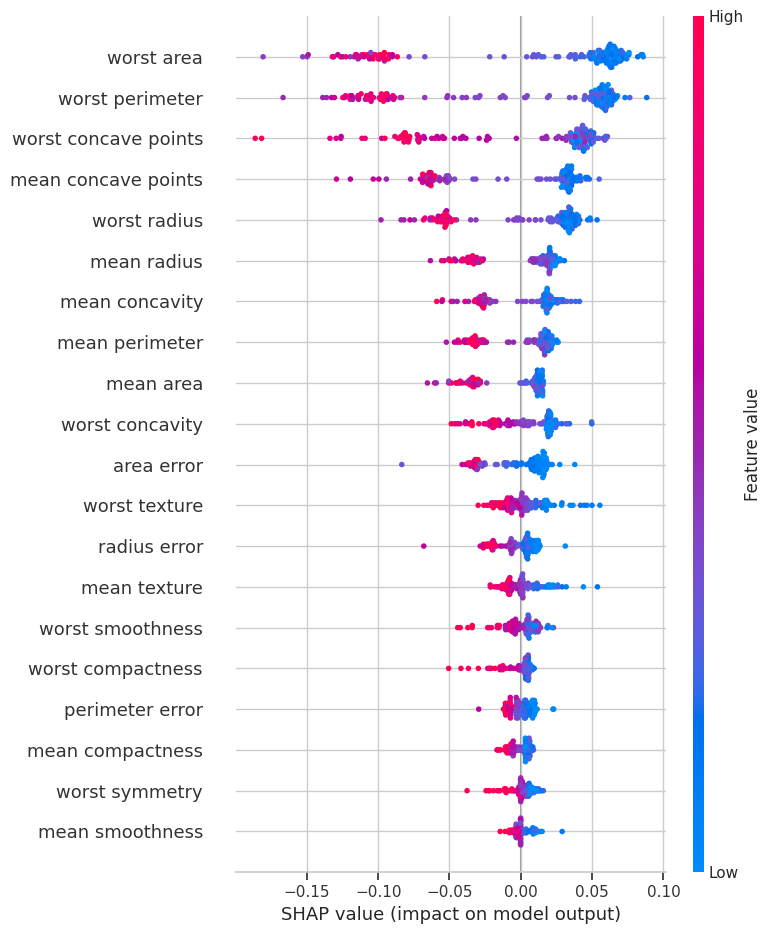

In [10]:
# ============================================
# 6. SHAP Global
# ============================================

# Creamos un TreeExplainer para nuestro modelo de árboles (Random Forest).
explainer_shap = shap.TreeExplainer(model)

# Calculamos los valores SHAP para el conjunto de prueba X_test.
# Para un problema de clasificación binaria, shap_values puede ser una lista de longitud 2
# (shap_values[0] para clase 0, shap_values[1] para clase 1)
# o un único array 3D (num_muestras, num_features, num_clases).
# Dada la estructura observada en el kernel, es un array 3D.
shap_values = explainer_shap.shap_values(X_test)

# Generamos un summary_plot para la clase 1 (benign).
# Cada punto es una instancia del dataset:
# - El eje Y muestra las características ordenadas por importancia.
# - El eje X muestra el valor SHAP (impacto en la predicción).
# - El color indica si el valor de la característica es alto (rojo) o bajo (azul).
# Se convierte X_test a un array NumPy y se seleccionan los SHAP values para la clase 1
# usando el slicing adecuado para el array 3D (todas las muestras, todas las características, clase 1).
shap.summary_plot(
    shap_values[:, :, 1], # SHAP values para la clase 1 (benign) de todas las muestras
    X_test.values,      # Datos de entrada como NumPy array
    feature_names=feature_names,
    show=True
)

Índice de la instancia explicada: 5
Clase real: malignant
Predicción del modelo: malignant


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


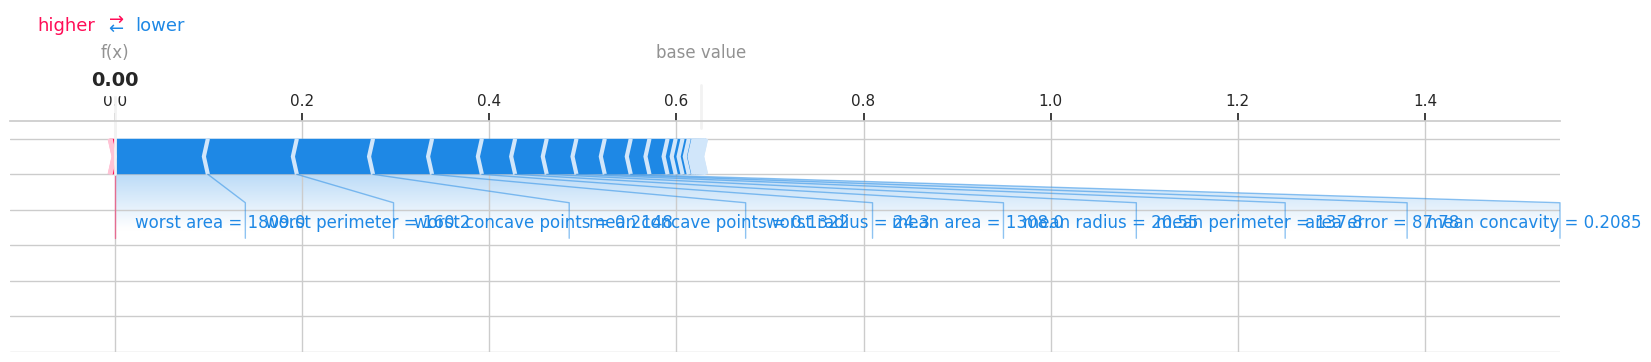

In [14]:
# ============================================
# 7. SHAP Local para una instancia específica
# ============================================

# Seleccionamos el índice de una instancia del conjunto de prueba.
# En un contexto real, podría ser el ID de un paciente específico.
instance_index = 5

# Extraemos los valores de las características de esa instancia.
instance = X_test.iloc[instance_index]

print("Índice de la instancia explicada:", instance_index)
print("Clase real:", class_names[y_test[instance_index]])
print("Predicción del modelo:", class_names[model.predict([instance.values])[0]])

# Generamos un force_plot para la clase 1 (benign) de esa instancia.
# - expected_value[1]: valor base de la predicción para la clase 1.
# - shap_values[instance_index, :, 1]: contribuciones de cada feature para esa instancia y clase 1.
# - instance: valores reales de las características para esa instancia.
shap.force_plot(
    explainer_shap.expected_value[1],
    shap_values[instance_index, :, 1],
    instance,
    matplotlib=True  # Usar versión estática (Matplotlib) para Colab
)

## Conclusiones detalladas

A continuación presentamos conclusiones amplias y detalladas basadas en los resultados obtenidos:

---

### 🧪 **1. Desempeño del modelo**

El modelo **Random Forest** alcanzó una precisión (accuracy) cercana al **96%**, lo que indica un desempeño sólido para distinguir entre tumores benignos y malignos.  

En términos clínicos, este rendimiento es aceptable, pero **no sustituye la evaluación médica**.  
Debe considerarse como **herramienta de apoyo**, no diagnóstico definitivo.

---

### 📊 **2. Importancia general de características**

Antes de aplicar SHAP, observamos la importancia clásica del modelo:

- Variables relacionadas con textura, radio, concavidad y área suelen aparecer como las más influyentes.
- Esto coincide con criterios utilizados en radiología real.
- Sin embargo, esta importancia es **global y no explica casos individuales**.

Aquí es donde SHAP añade valor.

---

### 🔍 **3. Interpretación global con SHAP**

El `summary_plot` mostró:

- Qué características influyen más en la predicción de la clase *benign*.
- Cómo influye cada valor alto o bajo (color azul/rojo).
- Qué variables generan mayor variabilidad en las predicciones.

Esto permite:

- Entender la “lógica general” del modelo.
- Validar si el modelo coincide con el razonamiento experto clínico.
- Detectar posibles patrones inesperados.

---

### 🩺 **4. Interpretación local de un paciente con SHAP**

El `force_plot` explicó **por qué un caso específico** fue clasificado como benigno o maligno.

SHAP permitió desglosar:

- Qué características aumentaron la probabilidad de que el tumor fuera benigno.
- Qué características empujaron la predicción hacia maligno.
- La magnitud exacta de cada contribución.

Esto es crítico en medicina porque:

- Da transparencia a cada decisión.
- Facilita la revisión por expertos.
- Permite identificar errores o sesgos en predicciones puntuales.

---

### 🛡 **5. Relevancia para un entorno real**

Si este modelo se implementara en un hospital:

- SHAP serviría como **mecanismo de interpretación obligatorio**.
- Permitiría evaluar decisiones dudosas caso por caso.
- Permitirá justificar el comportamiento del modelo ante comités reglamentarios.
- Proveería documentación clara para auditorías.

---

### 🧭 **6. Recomendaciones finales**

1. **No usar el modelo como diagnóstico** → solo apoyo.
2. Evaluar múltiples instancias con SHAP para detectar casos límite.
3. Integrar métricas adicionales como:
   - Sensibilidad (TPR)
   - Falsos negativos (muy críticos en cáncer)
4. Analizar fairness si se agregan variables demográficas.
5. Integrar SHAP en un pipeline de monitoreo en producción.

---

### ✔ Conclusión general

SHAP proporciona explicaciones claras, matemáticamente fundamentadas y accesibles tanto para técnicos como para médicos.  
Es indispensable si el modelo se utiliza para tomar decisiones críticas, como en diagnóstico asistido.

Este notebook demuestra cómo SHAP transforma un modelo de ML en una herramienta confiable, auditada y con transparencia.
"""